#### 학습목표
- 데이터 타입 : Series , DataFrame 
- Pandas 통해서 데이터분석과 시각화(matplotlib , seaborn, folium)
- 분석 : 기술적 통계 분석 , 탐색적 데이터 분석(EDA)

In [3]:
import numpy  as np 
import pandas as pd

def aryInfo(ary) : 
    print('type - ' , type(ary)) 
    print('shape - ' , ary.shape)
    print('ndim  - ' , ary.ndim)
    print('dtype - ' , ary.dtype)
    print()
    print('data  -')
    print(ary) 

- 파일 입출력(.csv) :  loadtxt() , savetxt() 

In [6]:
# file_path = r"C:\Users\user\data\기후통계분석.csv"
# rawData = np.loadtxt(file_path, dtype = 'U', skiprows = 1, delimiter = ',')

rawData = np.loadtxt('./data/기후통계분석.csv' , 
                    dtype='U',
                    skiprows = 1 , 
                    delimiter = ',')
# print('type - ' , type(rawData))
aryInfo(rawData)

type -  <class 'numpy.ndarray'>
shape -  (40414, 5)
ndim  -  2
dtype -  <U10

data  -
[['1907-10-01' '108' '13.5' '7.9' '20.7']
 ['1907-10-02' '108' '16.2' '7.9' '22']
 ['1907-10-03' '108' '16.2' '13.1' '21.3']
 ...
 ['2021-08-23' '108' '22.4' '21' '24']
 ['2021-08-24' '108' '23.4' '21.1' '26.4']
 ['2021-08-25' '108' '25' '23.5' '27.3']]


In [7]:
rawData[ 0 : 6 , : ]

array([['1907-10-01', '108', '13.5', '7.9', '20.7'],
       ['1907-10-02', '108', '16.2', '7.9', '22'],
       ['1907-10-03', '108', '16.2', '13.1', '21.3'],
       ['1907-10-04', '108', '16.5', '11.2', '22'],
       ['1907-10-05', '108', '17.6', '10.9', '25.4'],
       ['1907-10-06', '108', '13', '11.2', '21.3']], dtype='<U10')

In [9]:
temp = rawData[ : , -1]
# print(temp)
aryInfo(temp)

type -  <class 'numpy.ndarray'>
shape -  (40414,)
ndim  -  1
dtype -  <U10

data  -
['20.7' '22' '21.3' ... '24' '26.4' '27.3']


In [10]:
print('data - ' , temp[:10])

data -  ['20.7' '22' '21.3' '22' '25.4' '21.3' '16.1' '14.9' '21.1' '24.1']


In [11]:
temp = temp.astype(float)
print('data - ' , temp[:10])

data -  [20.7 22.  21.3 22.  25.4 21.3 16.1 14.9 21.1 24.1]


In [21]:
# Quiz 
# 최고기온이 가장 높은 년도의 기후정보를 확인하고 싶다면? 
print('max     - ' , np.max(temp))
print('argmax  - ' , np.argmax(temp))
print('argsort - ' , np.argsort(temp)[-1])
print('argsort - ' , np.argsort(temp)[::-1][0])
print()
print('answer  - ' , rawData[ np.argsort(temp)[::-1][0] , :  ])


max     -  39.6
argmax  -  39293
argsort -  39293
argsort -  39293

answer  -  ['2018-08-01' '108' '33.6' '27.8' '39.6']


In [23]:
# Quiz
# 평균기온이 가장 낮은 년도의 기후정보를 확인하고 싶다면?
temp = rawData[ : , 2]
aryInfo(temp)

type -  <class 'numpy.ndarray'>
shape -  (40414,)
ndim  -  1
dtype -  <U10

data  -
['13.5' '16.2' '16.2' ... '22.4' '23.4' '25']


In [27]:
print('answer - ' , rawData[  np.argmin(temp.astype(float)) , : ])

answer -  ['1915-01-13' '108' '-19.2' '-21.3' '-16.3']


- 벡터와 행렬을 연산할 수 있을까?
- 가능하다
- 왜? 브로드 캐스팅 때문에 

In [29]:
ary01 = np.arange(1, 100001)
ary02 = np.arange(100001, 200001)
print('len - ' , len(ary02) , len(ary02))

len -  100000 100000


In [31]:
tempAry = np.zeros_like(ary01)
print(tempAry , len(tempAry))

[0 0 0 ... 0 0 0] 100000


In [34]:
%%time
for idx in range(len(ary02)) :
    tempAry[idx] = ary01[idx] + ary02[idx]
print()
print('answer - ' , tempAry)


answer -  [100002 100004 100006 ... 299996 299998 300000]
CPU times: total: 62.5 ms
Wall time: 55.1 ms


In [35]:
%%time
tempAry = ary01 + ary02
print()
print('answer - ' , tempAry)


answer -  [100002 100004 100006 ... 299996 299998 300000]
CPU times: total: 0 ns
Wall time: 1.87 ms


In [48]:
ary01 = np.arange(3) 
print(ary01)
print(ary01 * 3)

[0 1 2]
[0 3 6]


In [47]:
ary02 = np.arange(12).reshape(-1, 4)
aryInfo(ary02)

type -  <class 'numpy.ndarray'>
shape -  (3, 4)
ndim  -  2
dtype -  int64

data  -
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [50]:
ary01[ :  , np.newaxis ] + ary02

array([[ 0,  1,  2,  3],
       [ 5,  6,  7,  8],
       [10, 11, 12, 13]])

- np.newaxis : 배열에 새로운 축(axis)을 추가해서 차원을 늘리는 역할 

In [42]:
ary = np.array([1,2,3,4])
aryInfo(ary)

type -  <class 'numpy.ndarray'>
shape -  (4,)
ndim  -  1
dtype -  int64

data  -
[1 2 3 4]


In [43]:
newAry = ary[ : , np.newaxis]
aryInfo(newAry)

type -  <class 'numpy.ndarray'>
shape -  (4, 1)
ndim  -  2
dtype -  int64

data  -
[[1]
 [2]
 [3]
 [4]]


In [44]:
newAry = ary[ np.newaxis, : ]
aryInfo(newAry)

type -  <class 'numpy.ndarray'>
shape -  (1, 4)
ndim  -  2
dtype -  int64

data  -
[[1 2 3 4]]


In [51]:
'''
series(index + value) 
index : 정수, 문자, 날짜, 시간 가능하고 중복허용 X
'''

'\nseries(index + value) \nindex : 정수, 문자, 날짜, 시간 가능하고 중복허용 X\n'

In [54]:
import numpy  as np 
import pandas as pd
import matplotlib.pyplot as plt 
import json   as j

# warning 제거
import warnings
warnings.filterwarnings('ignore')

print('numpy  version - ' , np.__version__)
print('pandas version - ' , pd.__version__)


numpy  version -  2.1.3
pandas version -  2.2.3


In [63]:
lst = [1,2,3,4,5]
print('type - ' , type(lst))

print()
ary = np.array(lst)
print('type - ' , type(ary))

print()
series = pd.Series(ary)
print('type - ' , type(series))
print()
print(series)
print('index  - ' , series.index)
print('values - ' , series.values , type(series.values))
print('dtype  - ' , series.dtype)

type -  <class 'list'>

type -  <class 'numpy.ndarray'>

type -  <class 'pandas.core.series.Series'>

0    1
1    2
2    3
3    4
4    5
dtype: int64
index  -  RangeIndex(start=0, stop=5, step=1)
values -  [1 2 3 4 5] <class 'numpy.ndarray'>
dtype  -  int64


In [148]:
def aryInfo(ary) : 
    print('type - ' , type(ary)) 
    print('shape - ' , ary.shape)
    print('ndim  - ' , ary.ndim)
    print('dtype - ' , ary.dtype)
    print()
    print('data  -')
    print(ary) 
    
def seriesInfo(s) :
    print('type   - ' , type(s)) 
    print('index  - ' , s.index)
    print('values - ' , s.values)
    print('dtype  - ' , s.dtype)
    print()
    print('data   - ')
    print(s) 

def frmInfo(frm) :
    print('type    - ' , type(frm))
    print('shape   - ' , frm.shape)
    print('ndim    - ' , frm.ndim)
    print('row idx - ' , frm.index , type(frm.index))
    print('col idx - ' , frm.columns , type(frm.columns))
    print('values  - ' , type(frm.values))
    print(frm.values)
    print('data - ') 
    print(frm)

In [67]:
# 문자인덱스로 시리즈 만든다면?
series = pd.Series({'idx01' : 1 , 'idx02' : 2, 'idx03' : 3}) 
seriesInfo(series)

type   -  <class 'pandas.core.series.Series'>
index  -  Index(['idx01', 'idx02', 'idx03'], dtype='object')
values -  [1 2 3]
dtype  -  int64

data   - 
idx01    1
idx02    2
idx03    3
dtype: int64


In [81]:
# series = pd.Series(data  = [1,2,3,4,5],
#                    index = ['서초', '송파', '강남', '삼성', '중구']) 
# seriesInfo(series)

series = pd.Series(data  = ('임섭순', '2025-11-04', 'Male' , True),
                   index = ['이름', '생년월일', '성별', '결혼여부']) 
series.name = '사용자 정보'
series.index.name = '신상 정보'
seriesInfo(series)

print()
print('indexing - ' , series[0] , series['이름'])
print('multi indexing - ')
print(series[[0,2]] , type(series[[0,2]]))
print(series[['이름', '성별']] , type(series[['이름', '성별']]))
print()
print('slicing - ' , series[ 0 : 3 ] , series[ '이름' : '성별' ] ) 

type   -  <class 'pandas.core.series.Series'>
index  -  Index(['이름', '생년월일', '성별', '결혼여부'], dtype='object', name='신상 정보')
values -  ['임섭순' '2025-11-04' 'Male' True]
dtype  -  object

data   - 
신상 정보
이름             임섭순
생년월일    2025-11-04
성별            Male
결혼여부          True
Name: 사용자 정보, dtype: object

indexing -  임섭순 임섭순
multi indexing - 
신상 정보
이름     임섭순
성별    Male
Name: 사용자 정보, dtype: object <class 'pandas.core.series.Series'>
신상 정보
이름     임섭순
성별    Male
Name: 사용자 정보, dtype: object <class 'pandas.core.series.Series'>

slicing -  신상 정보
이름             임섭순
생년월일    2025-11-04
성별            Male
Name: 사용자 정보, dtype: object 신상 정보
이름             임섭순
생년월일    2025-11-04
성별            Male
Name: 사용자 정보, dtype: object


In [82]:
print('dir - ' , dir(series))

dir -  ['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__column_consortium_standard__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__firstlineno__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce

In [84]:
keyLst = [ key for key in series.keys() ] 
print('key list   - ' , keyLst)
print()
valueLst = [ value for value in series.values ]
print('value list - ' , valueLst)

key list   -  ['이름', '생년월일', '성별', '결혼여부']

value list -  ['임섭순', '2025-11-04', 'Male', True]


In [90]:
series = pd.Series( range(10, 21) ) 
# seriesInfo(series)
print( series.values * 2 , type( series.values * 2 ) ) 
print('boolean indexing - ') 
print(series.values%2 == 0)
print( series.values[ series.values%2 == 0 ] )

[20 22 24 26 28 30 32 34 36 38 40] <class 'numpy.ndarray'>
boolean indexing - 
[ True False  True False  True False  True False  True False  True]
[10 12 14 16 18 20]


In [92]:
from datetime import date, datetime, timedelta 

In [96]:
today = date(2025, 11, 4)
print(today)

print(today + timedelta(days=1) )

2025-11-04
2025-11-05


In [101]:
# 오늘 날짜부터 10일간의 날짜를 생성하여 시리즈의 인덱스로 사용하고 싶다면?
idx = [ today + timedelta(day) for day in range(0, 10)]
print(idx)

[datetime.date(2025, 11, 4), datetime.date(2025, 11, 5), datetime.date(2025, 11, 6), datetime.date(2025, 11, 7), datetime.date(2025, 11, 8), datetime.date(2025, 11, 9), datetime.date(2025, 11, 10), datetime.date(2025, 11, 11), datetime.date(2025, 11, 12), datetime.date(2025, 11, 13)]


In [103]:
date_index = pd.date_range(start = today, periods = 10)
print(date_index)

DatetimeIndex(['2025-11-04', '2025-11-05', '2025-11-06', '2025-11-07',
               '2025-11-08', '2025-11-09', '2025-11-10', '2025-11-11',
               '2025-11-12', '2025-11-13'],
              dtype='datetime64[ns]', freq='D')


In [108]:
series = pd.Series(data  = [  np.random.randint(1, 100) for _ in range(10) ] ,
                   index = date_index)
print(series)

2025-11-04    87
2025-11-05    16
2025-11-06     8
2025-11-07    16
2025-11-08    76
2025-11-09    76
2025-11-10    47
2025-11-11    98
2025-11-12     3
2025-11-13    80
Freq: D, dtype: int64


In [109]:
print( series['2025-11-04'] )

87


In [111]:
# 결측값 , null : isnull() , notnull() 
series['2025-11-10'] = np.nan

In [112]:
series

2025-11-04    87.0
2025-11-05    16.0
2025-11-06     8.0
2025-11-07    16.0
2025-11-08    76.0
2025-11-09    76.0
2025-11-10     NaN
2025-11-11    98.0
2025-11-12     3.0
2025-11-13    80.0
Freq: D, dtype: float64

In [114]:
pd.isnull(series)
print()
pd.notnull(series)

2025-11-04     True
2025-11-05     True
2025-11-06     True
2025-11-07     True
2025-11-08     True
2025-11-09     True
2025-11-10    False
2025-11-11     True
2025-11-12     True
2025-11-13     True
Freq: D, dtype: bool

In [119]:
# 결측값은 평균이나 중위수의 값을 대체 
series[ pd.isnull(series)] = np.mean(series)
print(series)

2025-11-04    87.000000
2025-11-05    16.000000
2025-11-06     8.000000
2025-11-07    16.000000
2025-11-08    76.000000
2025-11-09    76.000000
2025-11-10    51.111111
2025-11-11    98.000000
2025-11-12     3.000000
2025-11-13    80.000000
Freq: D, dtype: float64


In [120]:
# fillna() : 결측값을 원하는 값을 채우고자 할 때 
series['2025-11-10'] = np.nan
print(series)

2025-11-04    87.0
2025-11-05    16.0
2025-11-06     8.0
2025-11-07    16.0
2025-11-08    76.0
2025-11-09    76.0
2025-11-10     NaN
2025-11-11    98.0
2025-11-12     3.0
2025-11-13    80.0
Freq: D, dtype: float64


In [123]:
series = series.fillna(0)
print(series)

2025-11-04    87.0
2025-11-05    16.0
2025-11-06     8.0
2025-11-07    16.0
2025-11-08    76.0
2025-11-09    76.0
2025-11-10     0.0
2025-11-11    98.0
2025-11-12     3.0
2025-11-13    80.0
Freq: D, dtype: float64


In [127]:
# subset 
series[3] = np.nan
series[8] = np.nan
print(series)

2025-11-04    87.0
2025-11-05    16.0
2025-11-06     8.0
2025-11-07     NaN
2025-11-08    76.0
2025-11-09    76.0
2025-11-10     0.0
2025-11-11    98.0
2025-11-12     NaN
2025-11-13    80.0
Freq: D, dtype: float64


In [129]:
# Quiz 
# 결측값을 제외한 subset 만들고 싶다면? 
subset = series[pd.notnull(series)]
print(subset)

2025-11-04    87.0
2025-11-05    16.0
2025-11-06     8.0
2025-11-08    76.0
2025-11-09    76.0
2025-11-10     0.0
2025-11-11    98.0
2025-11-13    80.0
dtype: float64


In [130]:
'''
DataFrame(표 형식 - 행, 열) : .csv
- 행 인덱스, 열 인덱스 
- pd.DataFrame(data= , columns=, index= )
- dict , [[]] ,
'''

'\nDataFrame(표 형식 - 행, 열) : .csv\n- 행 인덱스, 열 인덱스 \n- pd.DataFrame(data= , columns=, index= )\n- dict , [[]] ,\n'

In [140]:
frm = pd.DataFrame({
    'feature01' : [1,2,3],
    'feature02' : [1,2,3],
    'feature03' : [1,2,3]
})
print(frm)
print('type    - ' , type(frm))
print('shape   - ' , frm.shape)
print('ndim    - ' , frm.ndim)
print('row idx - ' , frm.index , type(frm.index))
print('col idx - ' , frm.columns , type(frm.columns))
print('values  - ' , type(frm.values))
print(frm.values)

   feature01  feature02  feature03
0          1          1          1
1          2          2          2
2          3          3          3
type    -  <class 'pandas.core.frame.DataFrame'>
shape   -  (3, 3)
ndim    -  2
row idx -  RangeIndex(start=0, stop=3, step=1) <class 'pandas.core.indexes.range.RangeIndex'>
col idx -  Index(['feature01', 'feature02', 'feature03'], dtype='object') <class 'pandas.core.indexes.base.Index'>
values  -  <class 'numpy.ndarray'>
[[1 1 1]
 [2 2 2]
 [3 3 3]]


In [149]:
frm = pd.DataFrame(data = 
                            [[1,2,3],
                            [1,2,3],
                            [1,2,3]],
                   columns = ['A', 'B', 'C'],
                   index   = [ 'user_'+str(idx) for idx in range(3)]
)

frmInfo(frm)

type    -  <class 'pandas.core.frame.DataFrame'>
shape   -  (3, 3)
ndim    -  2
row idx -  Index(['user_0', 'user_1', 'user_2'], dtype='object') <class 'pandas.core.indexes.base.Index'>
col idx -  Index(['A', 'B', 'C'], dtype='object') <class 'pandas.core.indexes.base.Index'>
values  -  <class 'numpy.ndarray'>
[[1 2 3]
 [1 2 3]
 [1 2 3]]
data - 
        A  B  C
user_0  1  2  3
user_1  1  2  3
user_2  1  2  3


In [152]:
print('전처리(pre-processing) - 열 이름 변경, 인덱스 변경 , rename() ') 
frm.rename(columns = { 'A' : 'name' ,  'B' : 'gender' , 'C' : 'isMarraige'} , 
           inplace = True,
           index   = { 'user_1' : 'customer01'}) 


전처리(pre-processing) - 열 이름 변경, 인덱스 변경 , rename() 


In [154]:
frmInfo(frm)

type    -  <class 'pandas.core.frame.DataFrame'>
shape   -  (3, 3)
ndim    -  2
row idx -  Index(['user_0', 'customer01', 'user_2'], dtype='object') <class 'pandas.core.indexes.base.Index'>
col idx -  Index(['name', 'gender', 'isMarraige'], dtype='object') <class 'pandas.core.indexes.base.Index'>
values  -  <class 'numpy.ndarray'>
[[1 2 3]
 [1 2 3]
 [1 2 3]]
data - 
            name  gender  isMarraige
user_0         1       2           3
customer01     1       2           3
user_2         1       2           3


In [161]:
print('데이터 추출 - indexing ') 
print('type - ' , type(frm['name']))

print(frm['name'] , type(frm['name']))

print(frm['name'].values , type(frm['name'].values))

데이터 추출 - indexing 
type -  <class 'pandas.core.series.Series'>
user_0        1
customer01    1
user_2        1
Name: name, dtype: int64 <class 'pandas.core.series.Series'>
[1 1 1] <class 'numpy.ndarray'>


In [162]:
print('데이터 추가 ') 
frm['age'] = [10, 20, 30]

데이터 추가 


In [172]:
frm

,name,gender,isMarraige
user_0,1,2,3
customer01,1,2,3
user_2,1,2,3


In [171]:
print('삭제 - 열 ')
del frm['age']
# del frm[['name', 'isMarraige']]

삭제 - 열 


KeyError: 'age'

In [182]:
print('만약 , 행 인덱싱을 하고 싶다면? - 정답 : 슬라이싱(정수, 문자) ') 
print(frm)
print()
print(frm[  : 2 ])
print()
print(frm[  : 'customer01' ])

만약 , 행 인덱싱을 하고 싶다면? - 정답 : 슬라이싱(정수, 문자) 
            name  gender  isMarraige
user_0         1       2           3
customer01     1       2           3
user_2         1       2           3

            name  gender  isMarraige
user_0         1       2           3
customer01     1       2           3

            name  gender  isMarraige
user_0         1       2           3
customer01     1       2           3


In [186]:
frm['name'][ : 'customer01']

user_0        1
customer01    1
Name: name, dtype: int64

- json 데이터를 분석을 위한 판다스 프레임으로

In [187]:
import urllib.request 
import json 


In [203]:
# sample json api 
endPoint = 'https://jsonplaceholder.typicode.com/posts'

response = urllib.request.urlopen(endPoint)

print('response - ')
# print(response.read())

# parsing
result =  json.loads(response.read()) 
# print(result)

print('type - ' , type(result))
print('keys - ' , result[0].keys() )

response - 
type -  <class 'list'>
keys -  dict_keys(['userId', 'id', 'title', 'body'])


In [204]:
frm = pd.DataFrame(result)

In [206]:
# frmInfo(frm)

In [210]:
# Quiz
# https://dummyjson.com/carts
# 해당 사이트로부터 json 데이터를 불러와 
# 각 장바구니의 userId, total, discountedTotal 그리고 포함된 각 product의 title, price, quantity
# 이걸 하나의 행으로 나타내는 DataFrame을 생성한다면?

import urllib.request 
import json

endPoint = 'https://dummyjson.com/carts'
response = urllib.request.urlopen(endPoint)
result =  json.loads(response.read())
# print(result)
print('type - ' , type(result))

type -  <class 'dict'>


In [215]:
carts = result['carts']
print('type - ' , type(carts))
rows = [] 
for cart in carts : 
    for prod in cart['products'] :
        rows.append({
            "userId" : cart["userId"], 
            "total"  : cart["total"],
            "discountedTotal" : cart["discountedTotal"],
            "title" : prod["title"], 
            "price" : prod["price"], 
            "quantity" : prod["quantity"]
        })
print('rows - ')
# print(rows)

type -  <class 'list'>
rows - 


In [216]:
frm = pd.DataFrame(rows)
print( frm.head() )

   userId      total  discountedTotal                                 title  \
0      33  103774.85         89686.65                       Charger SXT RWD   
1      33  103774.85         89686.65  Apple MacBook Pro 14 Inch Space Grey   
2      33  103774.85         89686.65                    Green Oval Earring   
3      33  103774.85         89686.65                         Apple Airpods   
4     142    4794.80          4288.95                        Cricket Helmet   

      price  quantity  
0  32999.99         3  
1   1999.99         2  
2     24.99         5  
3    129.99         5  
4     44.99         4  


In [220]:
# 통계 분석, 탐색적 데이터 분석 
# 브랜드별 평균 상품가 확인 

frm.groupby('title')['price'].mean().sort_values(ascending=False).head()

title
Charger SXT RWD            32999.99
Pacifica Touring           31999.99
300 Touring                28999.99
Rolex Cellini Moonphase    15999.99
Rolex Submariner Watch     13999.99
Name: price, dtype: float64

In [225]:
# 사용자별 총 구매액 
users = frm.groupby("userId")["total"].sum().sort_values(ascending=False).head()

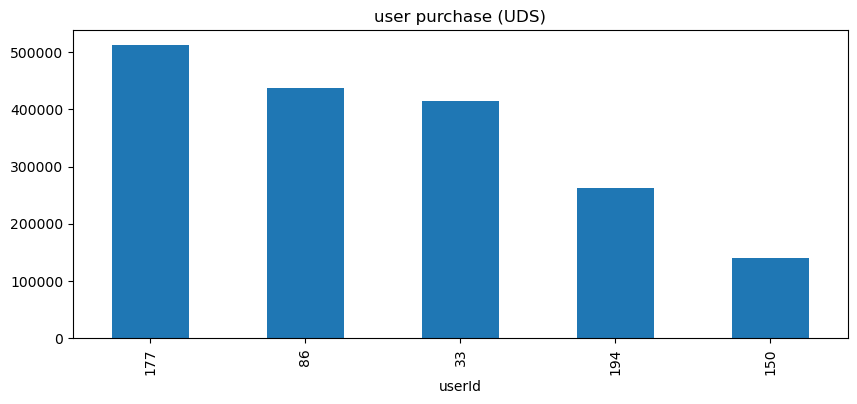

In [226]:
import matplotlib.pyplot as plt 

users.plot(kind='bar' , figsize=(10,4), title="user purchase (UDS)") 
plt.show()